# Project 2: Fraud Detection - Step 3: Explainability & Online Learning

This notebook implements explainability overlays and simulates an incremental learning streaming environment.

## Blueprint Actions Covered
* **Explainability**: Generating SHAP and LIME plots to detail exactly why specific transactions are flagged as fraudulent.
* **Online Learning**: Simulating streaming environments using incremental `.partial_fit()` (like SGDClassifier).

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.linear_model import SGDClassifier
import warnings
warnings.filterwarnings('ignore')

## 1. Load Preprocessed Datasets & serialized best model

We load the Standard Scaled features and target variables, alongside the best anomaly detection model (Local Outlier Factor) generated in Step 2.

In [2]:
OUTPUT_DIR = "outputs"
MODELS_DIR = "models"

# Load datasets
X_train = pd.read_csv(os.path.join(OUTPUT_DIR, "train_scaled_std.csv"))
X_val = pd.read_csv(os.path.join(OUTPUT_DIR, "val_scaled_std.csv"))
X_test = pd.read_csv(os.path.join(OUTPUT_DIR, "test_scaled_std.csv"))

y_train = pd.read_csv(os.path.join(OUTPUT_DIR, "y_train.csv")).values.ravel()
y_val = pd.read_csv(os.path.join(OUTPUT_DIR, "y_val.csv")).values.ravel()
y_test = pd.read_csv(os.path.join(OUTPUT_DIR, "y_test.csv")).values.ravel()

# Load anomaly detector
anomaly_payload = joblib.load(os.path.join(MODELS_DIR, "anomaly_detector.joblib"))
best_model = anomaly_payload['model']
best_model_name = anomaly_payload['model_name']
feature_names = X_train.columns.tolist()

print(f"Loaded best anomaly model: {best_model_name}")
print(f"Train features shape:      {X_train.shape}")

Loaded best anomaly model: Local Outlier Factor
Train features shape:      (7000, 11)


## 2. Model Explainability Probability-Mapping Wrapper

Model-agnostic explainers like LIME and SHAP expect classification predictions to return probability arrays. Since Local Outlier Factor outputs decision scores (density metric), we map the negated decision function to $[0, 1]$ using a sigmoid function to represent fraud probability.

In [3]:
def predict_proba_wrapper(X):
    # Get anomaly scores (higher = more anomalous/fraudulent)
    scores = -best_model.decision_function(X)
    # Sigmoid function to map to [0, 1]
    probs_fraud = 1 / (1 + np.exp(-scores))
    probs_normal = 1 - probs_fraud
    return np.column_stack([probs_normal, probs_fraud])

## 3. LIME Explainer

We use `lime` to generate a local feature attribution plot showing exactly why a specific transaction was flagged as fraudulent.

Explaining transaction at test index 32...


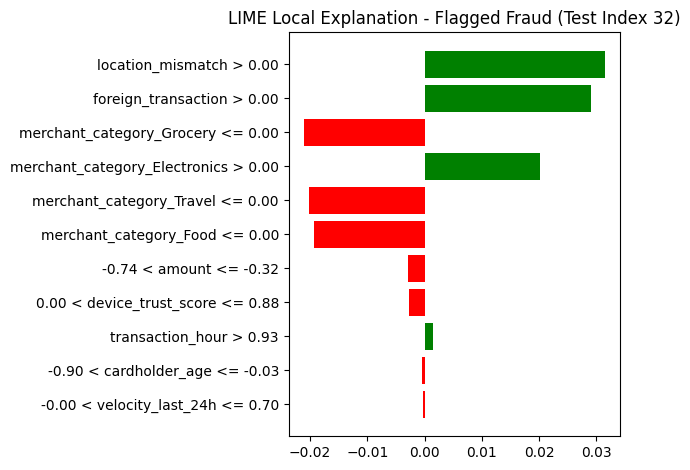

In [4]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

# Setup LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=feature_names,
    class_names=['Normal', 'Fraud'],
    mode='classification',
    random_state=42
)

# Find anomalous transactions in test split
test_preds_raw = best_model.predict(X_test.values)
anomaly_indices = np.where(test_preds_raw == -1)[0]

if len(anomaly_indices) > 0:
    target_idx = anomaly_indices[0]
    sample_to_explain = X_test.iloc[target_idx]
    
    print(f"Explaining transaction at test index {target_idx}...")
    
    # Generate LIME explanation
    exp = lime_explainer.explain_instance(
        data_row=sample_to_explain.values,
        predict_fn=predict_proba_wrapper,
        num_features=len(feature_names)
    )
    
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Local Explanation - Flagged Fraud (Test Index {target_idx})")
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, "03_lime_explanation.png"), dpi=150)
    plt.show()
else:
    print("No test set anomalies found to explain.")

## 4. SHAP Explainer

We use SHAP KernelExplainer to analyze global feature importances across a subset of 30 test transactions.

Initializing SHAP KernelExplainer...
Computing SHAP values for 30 observations...


  0%|                                                    | 0/30 [00:00<?, ?it/s]

  3%|█▍                                          | 1/30 [00:02<01:15,  2.60s/it]

  7%|██▉                                         | 2/30 [00:05<01:22,  2.96s/it]

 10%|████▍                                       | 3/30 [00:09<01:27,  3.22s/it]

...

 90%|██████████████████████████████████████▋    | 27/30 [01:12<00:09,  3.04s/it]

 93%|████████████████████████████████████████▏  | 28/30 [01:14<00:05,  2.86s/it]

 97%|█████████████████████████████████████████▌ | 29/30 [01:16<00:02,  2.67s/it]

100%|███████████████████████████████████████████| 30/30 [01:19<00:00,  2.69s/it]

100%|███████████████████████████████████████████| 30/30 [01:19<00:00,  2.66s/it]

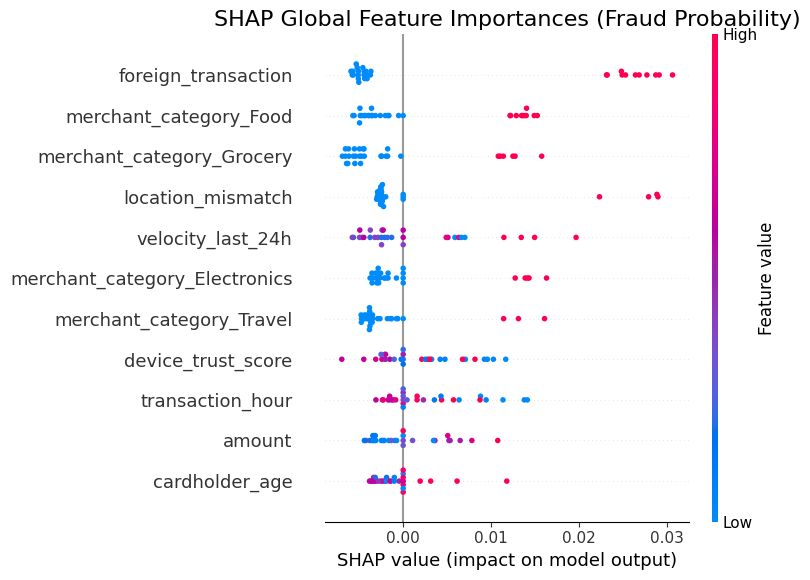

In [5]:
import shap

print("Initializing SHAP KernelExplainer...")
# Use 50 training rows as background reference to speed up calculation
background_data = X_train.values[:50]
shap_explainer = shap.KernelExplainer(predict_proba_wrapper, background_data)

# Create subset of test data (20 normal, 10 fraud)
test_sample_indices = np.concatenate([
    np.where(y_test == 0)[0][:20],
    np.where(y_test == 1)[0][:10]
])
X_shap_eval = X_test.iloc[test_sample_indices].values

print(f"Computing SHAP values for {len(X_shap_eval)} observations...")
shap_values = shap_explainer.shap_values(X_shap_eval)

# Extract SHAP values for positive fraud class
if isinstance(shap_values, list):
    shap_vals_fraud = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_vals_fraud = shap_values[:, :, 1]
else:
    shap_vals_fraud = shap_values

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_vals_fraud, X_shap_eval, feature_names=feature_names, show=False)
plt.title("SHAP Global Feature Importances (Fraud Probability)", fontsize=16)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "03_shap_summary.png"), dpi=150)
plt.show()

## 5. Simulated Online Learning Stream

We simulate a streaming data environment by training an `SGDClassifier` incrementally in sequential batches of size **256**, mimicking real-time card transactions. We evaluate the F1-Score, Recall, and Accuracy of the model on the validation split as it updates.

In [6]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

print("Initializing SGDClassifier for incremental streaming simulation...")
sgd_clf = SGDClassifier(loss='log_loss', random_state=42, learning_rate='constant', eta0=0.01)

batch_size = 256
n_samples = X_train.shape[0]

batches = []
accuracies = []
recalls = []
f1_scores = []

batch_count = 0
for start_idx in range(0, n_samples, batch_size):
    end_idx = min(start_idx + batch_size, n_samples)
    X_batch = X_train.iloc[start_idx:end_idx].values
    y_batch = y_train[start_idx:end_idx]
    
    # Incrementally train model parameters on current streaming batch
    sgd_clf.partial_fit(X_batch, y_batch, classes=np.array([0, 1]))
    
    # Evaluate updated model on validation split
    y_val_pred = sgd_clf.predict(X_val.values)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_rec = recall_score(y_val, y_val_pred, zero_division=0)
    val_f1 = f1_score(y_val, y_val_pred, zero_division=0)
    
    batch_count += 1
    batches.append(batch_count)
    accuracies.append(val_acc)
    recalls.append(val_rec)
    f1_scores.append(val_f1)
    
    if batch_count % 5 == 0 or end_idx == n_samples:
        print(f"Batch {batch_count:02d} processed: Samples seen = {end_idx:5d} | "
              f"Val Accuracy = {val_acc:.4f} | Val F1 = {val_f1:.4f} | Val Recall = {val_rec:.4f}")

print("\nOnline Learning Simulation completed successfully.")

Initializing SGDClassifier for incremental streaming simulation...
Batch 05 processed: Samples seen =  1280 | Val Accuracy = 0.9847 | Val F1 = 0.0000 | Val Recall = 0.0000
Batch 10 processed: Samples seen =  2560 | Val Accuracy = 0.9847 | Val F1 = 0.0000 | Val Recall = 0.0000
Batch 15 processed: Samples seen =  3840 | Val Accuracy = 0.9847 | Val F1 = 0.0000 | Val Recall = 0.0000
Batch 20 processed: Samples seen =  5120 | Val Accuracy = 0.9847 | Val F1 = 0.0000 | Val Recall = 0.0000


Batch 25 processed: Samples seen =  6400 | Val Accuracy = 0.9847 | Val F1 = 0.0000 | Val Recall = 0.0000
Batch 28 processed: Samples seen =  7000 | Val Accuracy = 0.9847 | Val F1 = 0.0000 | Val Recall = 0.0000

Online Learning Simulation completed successfully.


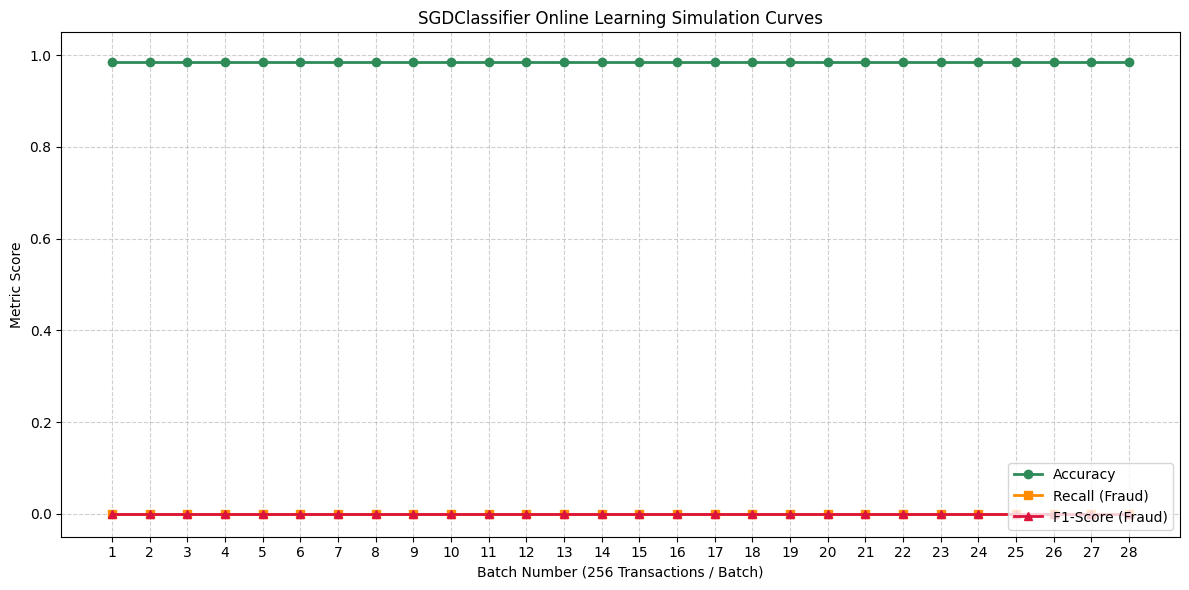

In [7]:
# Plot online learning curves
plt.figure(figsize=(12, 6))
plt.plot(batches, accuracies, marker='o', label='Accuracy', color='seagreen', lw=2)
plt.plot(batches, recalls, marker='s', label='Recall (Fraud)', color='darkorange', lw=2)
plt.plot(batches, f1_scores, marker='^', label='F1-Score (Fraud)', color='crimson', lw=2)
plt.title('SGDClassifier Online Learning Simulation Curves')
plt.xlabel('Batch Number (256 Transactions / Batch)')
plt.ylabel('Metric Score')
plt.ylim(-0.05, 1.05)
plt.xticks(batches)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "03_streaming_learning_curve.png"), dpi=150)
plt.show()

## 6. Model Serialization

In [8]:
joblib.dump(sgd_clf, os.path.join(MODELS_DIR, "online_sgd_clf.joblib"))
print("Online SGD Classifier successfully saved to models/online_sgd_clf.joblib")

Online SGD Classifier successfully saved to models/online_sgd_clf.joblib
